# Tiny model for CIFAR10

## Configuration

Imports

In [1]:
import math
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt

from tqdm import tqdm, trange

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets
import torchvision.transforms.v2 as transforms

Configuration

In [2]:
DATA_DIR='./data'

NUM_CLASSES = 10
NUM_WORKERS = 8
BATCH_SIZE = 32
EPOCHS = 2000
LEARNING_RATE = 1e-2
WEIGHT_DECAY = 1e-3

In [3]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("device:", DEVICE)

device: cuda


## Data

In [4]:
train_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4, padding_mode='reflect'),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToDtype(torch.float, scale=True),
    transforms.RandomErasing(p=1.0, value=0.)
])

In [5]:
val_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float, scale=True),
])

In [6]:
train_dset = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=train_transform)
test_dset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=val_transform)

In [7]:
train_loader = torch.utils.data.DataLoader(train_dset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
test_loader = torch.utils.data.DataLoader(test_dset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

In [8]:
def dataset_show_image(dset, idx):
    X, Y = dset[idx]
    title = "Ground truth: {}".format(dset.classes[Y])
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.set_axis_off()
    ax.imshow(np.moveaxis(X.numpy(), 0, -1))
    ax.set_title(title)
    plt.show()

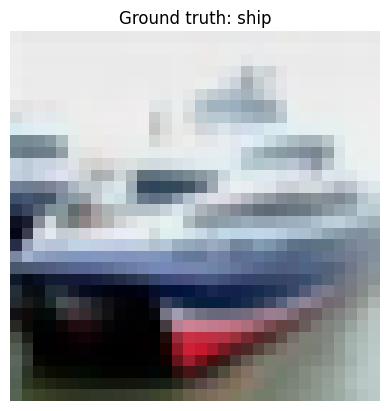

In [9]:
dataset_show_image(test_dset, 1)

## Model

From [arXiv:1904.11486 [cs.CV]](https://arxiv.org/abs/1904.11486)

In [10]:
class BlurPool(nn.Module):
    def __init__(self, stride=2, filter_size=4):
        super().__init__()
        self.stride = stride
        self.padding = (filter_size - stride) // 2
        self.register_buffer("filt", self.get_filter(filter_size))

    def forward(self, x):
        channels = x.size(1)
        filt = self.filt.expand(channels, 1, -1, -1)
        x = F.conv2d(x, filt, stride=self.stride, padding=self.padding, groups=channels)
        return x

    def get_filter(self, size):
        filt = torch.tensor(self.binomial_coefficients(size - 1)).float()
        filt = filt[:, None] * filt[None, :]
        filt = filt / filt.sum()  # normalize
        filt = filt[None, None, :, :]
        return filt

    @staticmethod
    def binomial_coefficients(n):
        coef = 1
        coefs = [coef]
        for d in range(1, n + 1):
            coef = coef * (n + 1 - d) // d
            coefs.append(coef)
        return coefs

ECA channel attention, [arXiv:1910.03151 [cs.CV]](https://arxiv.org/abs/1910.03151)

In [11]:
class ECA(nn.Module):
    def __init__(self, channels):
        super().__init__()
        k_size = self.get_k_size(channels)
        padding = (k_size - 1) // 2

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k_size, padding=padding)

    def forward(self, x):
        s = self.pool(x)
        c = s.size(1)
        s = s.view(-1, 1, c)
        s = self.conv(s)
        s = s.view(-1, c, 1, 1)
        s = torch.sigmoid(s)

        return x * s

    @staticmethod
    def get_k_size(channels, gamma=2, b=1):
        t = int(abs((math.log(channels, 2) + b) / gamma))
        k = t if t % 2 else t + 1
        return k

In [12]:
class NormAct(nn.Sequential):
    def __init__(self, channels):
        super().__init__(
            nn.BatchNorm2d(channels),
            nn.GELU()
        )

Block

In [13]:
class SpatialMixer(nn.Sequential):
    def __init__(self, channels, stride=1):
        super().__init__(
            nn.Conv2d(channels, channels, 3, padding=1, groups=channels, bias=False),
            NormAct(channels)
        )
        if stride > 1:
            self.insert(0, BlurPool(stride, filter_size=6))

In [14]:
class ChannelMixer(nn.Sequential):
    def __init__(self, channels):
        mid_channels = channels // 2
        super().__init__(
            nn.Conv2d(channels, mid_channels, 1, bias=False),
            NormAct(mid_channels),
            nn.Conv2d(mid_channels, channels, 1, bias=False)
        )

In [15]:
class ResidualBlock(nn.Module):
    def __init__(self, channels, stride=1, p_drop=0.):
        super().__init__()
        self.shortcut = nn.Dropout(p_drop)
        if stride > 1:
            self.shortcut = nn.Sequential(
                nn.AvgPool2d(stride),
                self.shortcut
            )
        self.residual = nn.Sequential(
            NormAct(channels),
            SpatialMixer(channels, stride),
            ECA(channels),
            ChannelMixer(channels)
        )
        self.γ = nn.Parameter(torch.tensor(0.))

    def forward(self, x):
        out = self.shortcut(x) + self.γ * self.residual(x)
        return out

Main model

In [16]:
class Head(nn.Sequential):
    def __init__(self, channels, classes, p_drop=0.):
        super().__init__(
            NormAct(channels),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(p_drop),
            nn.Linear(channels, classes)
        )

In [17]:
class Stem(nn.Sequential):
    def __init__(self, in_channels, out_channels, mid_channels=32):
        super().__init__(
            nn.Conv2d(in_channels, mid_channels, 3, padding=1, bias=False),
            NormAct(mid_channels),
            nn.Conv2d(mid_channels, out_channels, 1, bias=False)
        )

In [18]:
class Net(nn.Sequential):
    def __init__(self, classes, width=32, in_channels=3, res_p_drop=0., head_p_drop=0.):
        strides = [1] + [2, 1] * 3
        super().__init__(
            Stem(in_channels, width),
            *[ResidualBlock(width, stride=stride, p_drop=res_p_drop) for stride in strides],
            Head(width, classes, p_drop=head_p_drop)
        )

In [19]:
def reset_parameters(model):
    for m in model.modules():
        if isinstance(m, (nn.Linear, nn.Conv2d)):
            nn.init.xavier_normal_(m.weight)
            if m.bias is not None: nn.init.zeros_(m.bias)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.constant_(m.weight, 1.)
            nn.init.zeros_(m.bias)
        elif isinstance(m, ResidualBlock):
            nn.init.zeros_(m.γ)

In [20]:
model = Net(NUM_CLASSES, width=96, res_p_drop=0.1, head_p_drop=0.1).to(DEVICE)

In [21]:
reset_parameters(model)

In [22]:
print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))

Number of parameters: 79,117


## Training

### Training functions

In [23]:
def iterate(step_fn, loader):
    num_samples = 0
    total_loss = 0.
    num_correct = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        loss, out = step_fn(x, y)
        pred = out.argmax(axis=-1)
        correct = (pred == y)
        loss, correct = loss.cpu().numpy(), correct.cpu().numpy()
        num_samples += correct.shape[0]
        total_loss += loss
        num_correct += np.sum(correct)
    
    avg_loss = total_loss / num_samples
    acc = num_correct / num_samples
    metrics = {"loss": avg_loss, "acc": acc}
    return metrics

In [24]:
def train(model, loss_fn, optimizer, loader, batch_scheduler):
    def train_step(x, y):
        out = model(x)
        loss = loss_fn(out, y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batch_scheduler.step()
        return loss.detach(), out.detach()

    model.train()
    metrics = iterate(train_step, loader)
    return metrics

In [25]:
def evaluate(model, loss_fn, loader):
    def eval_step(x, y):
        out = model(x)
        loss = loss_fn(out, y)
        return loss.detach(), out.detach()

    model.eval()
    with torch.inference_mode():
        metrics = iterate(eval_step, loader)
    return metrics

In [26]:
def update_history(history, metrics, name):
    for key, val in metrics.items():
        history[name + ' ' + key].append(val)

In [27]:
def history_plot_train_val(history, key):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    xs = np.arange(1, len(history['train ' + key]) + 1)
    ax.plot(xs, history['train ' + key], '.-', label='train')
    ax.plot(xs, history['val ' + key], '.-', label='val')
    ax.set_xlabel('epoch')
    ax.set_ylabel(key)
    ax.legend()
    ax.grid()
    plt.show()

### Start training

In [28]:
loss = nn.CrossEntropyLoss()

In [29]:
optimizer = optim.AdamW([p for p in model.parameters() if p.requires_grad],
                        lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

In [30]:
lr_scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LEARNING_RATE,
                                             steps_per_epoch=len(train_loader), epochs=EPOCHS)

In [31]:
history = defaultdict(list)

In [32]:
pbar = trange(EPOCHS, ncols=140)
for epoch in pbar:
    train_metrics = train(model, loss, optimizer, train_loader, lr_scheduler)
    update_history(history, train_metrics, "train")
    
    val_metrics = evaluate(model, loss, test_loader)
    update_history(history, val_metrics, "val")
    pbar.set_postfix({"acc": train_metrics['acc'], "val acc": val_metrics['acc']})

  0%|                                                                                                              | 0/2000 [00:00<?, ?it/s]

  0%|                                                                                    | 0/2000 [00:38<?, ?it/s, acc=0.376, val acc=0.572]

  0%|                                                                         | 1/2000 [00:38<21:37:16, 38.94s/it, acc=0.376, val acc=0.572]

  0%|                                                                         | 1/2000 [01:16<21:37:16, 38.94s/it, acc=0.526, val acc=0.635]

  0%|                                                                         | 2/2000 [01:16<21:18:01, 38.38s/it, acc=0.526, val acc=0.635]

...

100%|█████████████████████████████████████████████████████████████████████▉| 1998/2000 [23:20:45<01:24, 42.49s/it, acc=0.967, val acc=0.946]

100%|█████████████████████████████████████████████████████████████████████▉| 1999/2000 [23:20:45<00:42, 42.19s/it, acc=0.967, val acc=0.946]

100%|█████████████████████████████████████████████████████████████████████▉| 1999/2000 [23:21:26<00:42, 42.19s/it, acc=0.968, val acc=0.946]

100%|██████████████████████████████████████████████████████████████████████| 2000/2000 [23:21:26<00:00, 41.87s/it, acc=0.968, val acc=0.946]

100%|██████████████████████████████████████████████████████████████████████| 2000/2000 [23:21:26<00:00, 42.04s/it, acc=0.968, val acc=0.946]

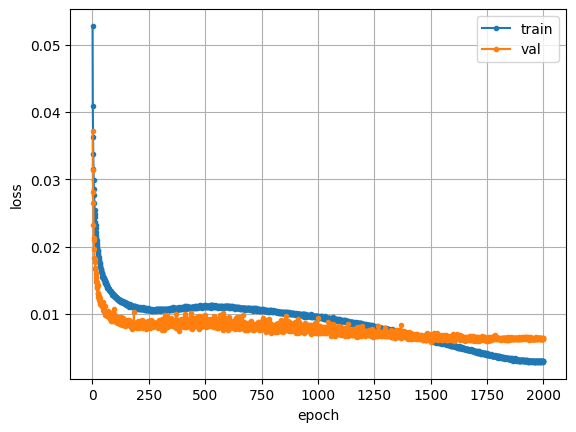

In [33]:
history_plot_train_val(history, 'loss')

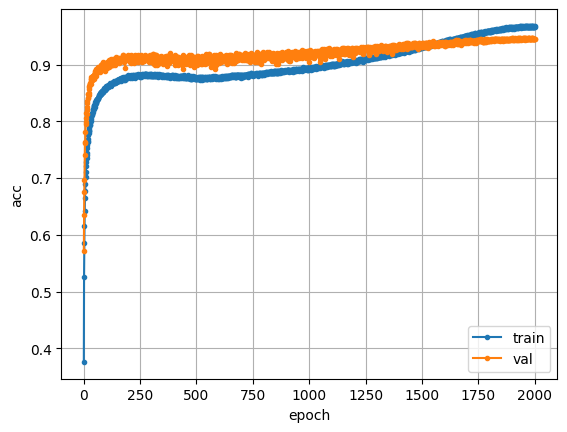

In [34]:
history_plot_train_val(history, 'acc')